# 04 Agrupamiento climatico de municipios del Magdalena

Version simplificada, para el Magdalena, de la idea del articulo *Analysis of Dengue
Prediction Generalization at Municipal Level in Colombia Using Climate-Based Clustering*.

No se replica el pipeline de pronostico. Solo se responde:

- Con las variables climaticas de cada municipio, ¿cuantos grupos encuentra K-Means y como los arma?
- ¿Coincide ese agrupamiento con la division administrativa en subregiones (`subregiones.csv`)?

Fuente climatica: ERA5 diario por municipio (notebook 02). Cartografia: geojson municipal DANE.

# 1 Configuracion

In [1]:
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
DATA = ROOT / "data"

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 110

def norm(s):
    return unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().upper().strip()

In [2]:
era = pd.read_parquet(DATA / "external" / "clima_era5_magdalena_diario.parquet")
sub = pd.read_csv(DATA / "raw" / "subregiones.csv")

# clave de union por nombre normalizado (ERA5 en mayusculas, sin tildes)
sub["key"] = sub["nombre_municipio"].map(norm)
era["key"] = era["municipio"].map(norm).replace({"CERRO DE SAN ANTONIO": "CERRO SAN ANTONIO"})

print(era["fecha"].min().date(), "->", era["fecha"].max().date(), "|", era["key"].nunique(), "municipios")
sub["subregion"].value_counts()

2007-01-01 -> 2024-12-31 | 30 municipios


subregion
Rio            9
Sur            7
Norte          7
Centro         6
Santa Marta    1
Name: count, dtype: int64

# 2 Perfil climatico por municipio

Cada municipio se resume por su promedio de largo plazo (2007-2024) en cuatro descriptores:
temperatura media, amplitud termica diaria (max - min), precipitacion y humedad.

In [3]:
era["amplitud"] = era["t2m_max"] - era["t2m_min"]

perfil = (
    era.groupby("key")
    .agg(
        t_media=("t2m_media", "mean"),
        amplitud=("amplitud", "mean"),
        precip=("precipitacion", "mean"),
        humedad=("humedad", "mean"),
    )
    .reset_index()
    .merge(sub, on="key")
)
# precipitacion sesgada a la derecha -> log (como en el articulo)
perfil["log_precip"] = np.log1p(perfil["precip"])
print("sesgo precip:", round(perfil["precip"].skew(), 2))

perfil[["nombre_municipio", "subregion", "t_media", "amplitud", "precip", "humedad"]].round(2)

sesgo precip: 1.75


,nombre_municipio,subregion,t_media,amplitud,precip,humedad
0,Algarrobo,Norte,28.190001,9.59,4.46,76.239998
1,Aracataca,Norte,19.549999,6.80,18.26,83.440002
2,Ariguani,Centro,28.530001,9.54,5.95,75.809998
3,Cerro San Antonio,Rio,29.040001,8.53,2.89,76.730003
4,Chivolo,Centro,28.110001,9.05,4.47,78.959999
5,Cienaga,Norte,20.660000,6.40,13.75,84.790001
6,Concordia,Rio,28.760000,8.53,2.89,76.690002
7,El Banco,Sur,28.610001,6.76,6.20,82.629997
8,El Pinon,Rio,28.799999,8.53,2.89,76.690002
9,El Reten,Norte,28.309999,6.47,8.28,79.820000


# 3 Estructura de las variables

Correlacion entre los cuatro descriptores. Sirve para ver si aportan informacion distinta
o si se reducen a un solo gradiente.

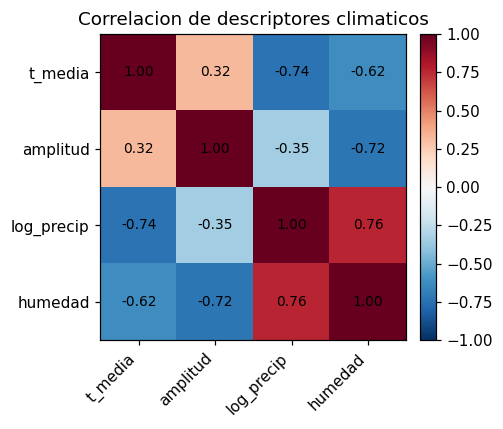

In [4]:
feats = ["t_media", "amplitud", "log_precip", "humedad"]
corr = perfil[feats].corr()

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=45, ha="right")
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats)
for i in range(len(feats)):
    for j in range(len(feats)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlacion de descriptores climaticos")
plt.tight_layout(); plt.show()

Temperatura, precipitacion y humedad estan fuertemente correlacionadas: describen un mismo
gradiente (zonas frias-humedas de la Sierra Nevada frente a tierras bajas calidas-secas).
La amplitud termica es el descriptor mas independiente.

# 4 K-Means: ¿cuantos grupos?

Se estandarizan las variables y se barre K de 2 a 7. Se usa el codo (inercia), el coeficiente
de silueta y el indice Davies-Bouldin para decidir el numero de grupos.

In [5]:
X = StandardScaler().fit_transform(perfil[feats])

rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=25, random_state=RANDOM_STATE).fit(X)
    rows.append({
        "k": k,
        "inercia": km.inertia_,
        "silueta": silhouette_score(X, km.labels_),
        "davies_bouldin": davies_bouldin_score(X, km.labels_),
    })
barrido = pd.DataFrame(rows).set_index("k")
barrido.round(3)

,inercia,silueta,davies_bouldin
k,,,
2,59.880,0.475,0.895
3,28.452,0.548,0.708
4,17.455,0.586,0.482
5,12.275,0.578,0.459
6,8.724,0.589,0.542
7,6.234,0.570,0.477


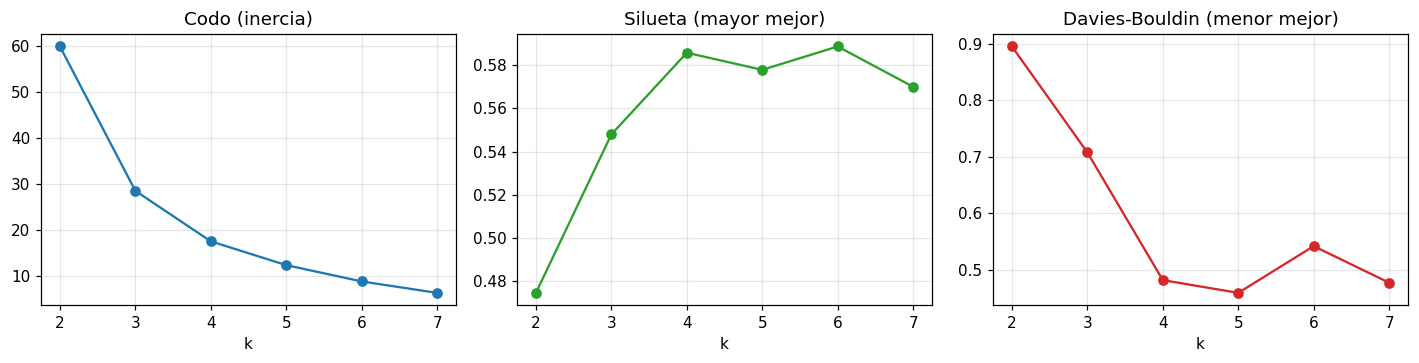

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(barrido.index, barrido["inercia"], "o-"); axes[0].set_title("Codo (inercia)")
axes[1].plot(barrido.index, barrido["silueta"], "o-", color="#2ca02c"); axes[1].set_title("Silueta (mayor mejor)")
axes[2].plot(barrido.index, barrido["davies_bouldin"], "o-", color="#d62728"); axes[2].set_title("Davies-Bouldin (menor mejor)")
for ax in axes:
    ax.set_xlabel("k"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
# eleccion: mejor silueta en el rango interpretable 3-5 (evita fragmentar 30 municipios)
K = int(barrido.loc[3:5, "silueta"].idxmax())
print("K seleccionado:", K)

K seleccionado: 4


# 5 Asignacion y caracterizacion de los grupos

In [8]:
km = KMeans(n_clusters=K, n_init=25, random_state=RANDOM_STATE).fit(X)
perfil["cluster"] = km.labels_

carac = perfil.groupby("cluster")[["t_media", "amplitud", "precip", "humedad"]].mean()
carac["n"] = perfil["cluster"].value_counts().sort_index()

# etiqueta climatica legible derivada de la caracterizacion
def etiqueta(r):
    if r["t_media"] < 24:      return "Frio-humedo (Sierra Nevada)"
    if r["amplitud"] < 5.5:    return "Baja amplitud (cienaga/rio)"
    if r["precip"] > 6:        return "Calido-humedo"
    return "Calido-seco"

carac["etiqueta"] = carac.apply(etiqueta, axis=1)
perfil["etiqueta"] = perfil["cluster"].map(carac["etiqueta"])
carac.round(2)

,t_media,amplitud,precip,humedad,n,etiqueta
cluster,,,,,,
0,28.660000,8.97,3.74,76.809998,16,Calido-seco
1,28.520000,7.20,7.19,80.720001,8,Calido-humedo
2,20.280001,6.83,13.70,83.459999,4,Frio-humedo (Sierra Nevada)
3,27.850000,4.07,2.93,80.919998,2,Baja amplitud (cienaga/rio)


In [9]:
for c in sorted(perfil["cluster"].unique()):
    ms = perfil.loc[perfil["cluster"] == c, "nombre_municipio"].tolist()
    print(f"Cluster {c} — {carac.loc[c, 'etiqueta']} ({len(ms)}): {', '.join(ms)}")

Cluster 0 — Calido-seco (16): Algarrobo, Ariguani, Cerro San Antonio, Chivolo, Concordia, El Pinon, Nueva Granada, Pedraza, Pijino del Carmen, Pivijay, Plato, Sabanas de San Angel, Santa Ana, Santa Barbara de Pinto, Tenerife, Zapayan
Cluster 1 — Calido-humedo (8): El Banco, El Reten, Guamal, Puebloviejo, Salamina, San Sebastian de Buenavista, San Zenon, Zona Bananera
Cluster 2 — Frio-humedo (Sierra Nevada) (4): Aracataca, Cienaga, Fundacion, Santa Marta
Cluster 3 — Baja amplitud (cienaga/rio) (2): Remolino, Sitionuevo


# 6 Subregiones administrativas vs K-Means

Tabla de contingencia y el indice Rand ajustado (ARI): mide cuanto coinciden ambas
particiones (1 = identicas, 0 = coincidencia aleatoria).

In [10]:
ct = pd.crosstab(perfil["subregion"], perfil["cluster"])
sub_codes = perfil["subregion"].astype("category").cat.codes
ari = adjusted_rand_score(sub_codes, perfil["cluster"])
print("ARI (subregion vs K-Means):", round(ari, 3))
ct

ARI (subregion vs K-Means): 0.142


cluster,0,1,2,3
subregion,,,,
Centro,6,0,0,0
Norte,1,3,3,0
Rio,6,1,0,2
Santa Marta,0,0,1,0
Sur,3,4,0,0


## 6.1 Los dos mapas

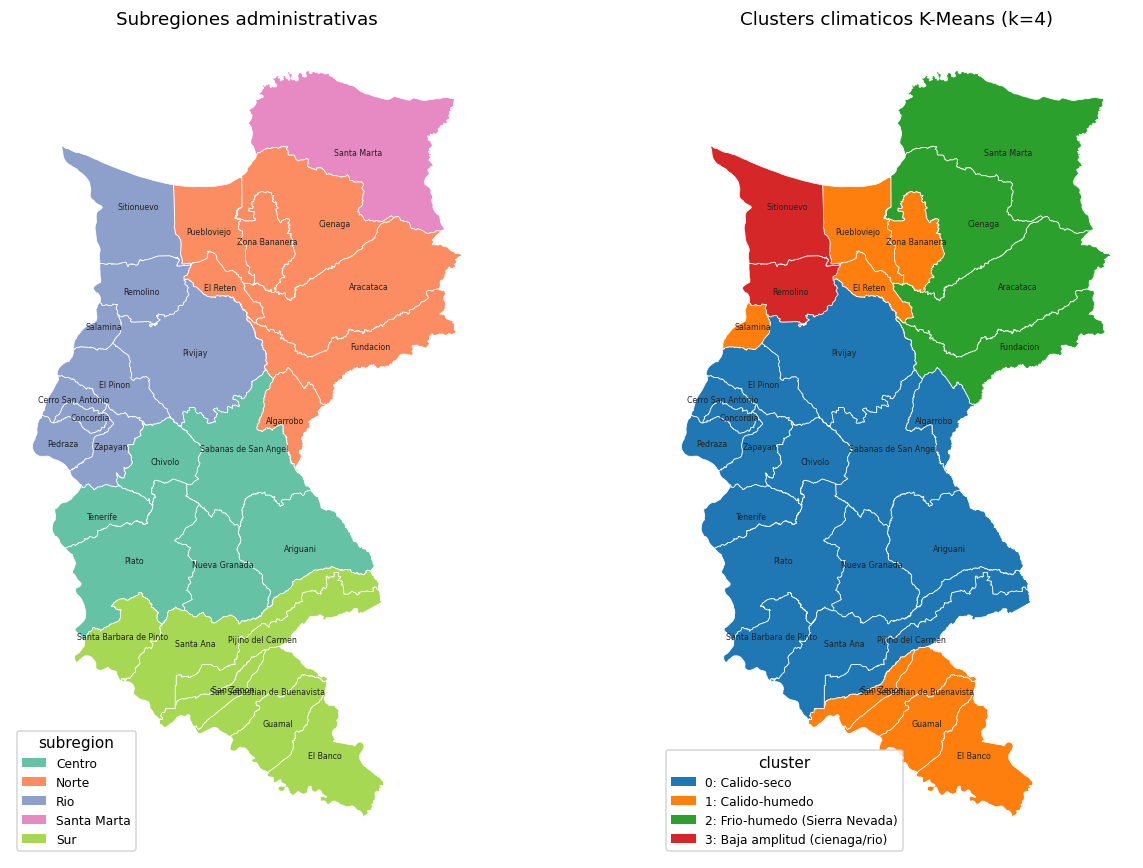

In [11]:
gdf = gpd.read_file(DATA / "raw" / "MGN_ADM_MPIO_GRAFICO.geojson")
mag = gdf[gdf["dpto_ccdgo"] == "47"].copy()
mag["cod_municipio"] = mag["mpio_cdpmp"].astype(int)
mag = mag.merge(perfil, on="cod_municipio")

# colores
subs = sorted(perfil["subregion"].unique())
sub_cmap = dict(zip(subs, plt.cm.Set2.colors))
clu = sorted(perfil["cluster"].unique())
clu_cmap = dict(zip(clu, plt.cm.tab10.colors))
mag["c_sub"] = mag["subregion"].map(sub_cmap)
mag["c_clu"] = mag["cluster"].map(clu_cmap)

fig, axes = plt.subplots(1, 2, figsize=(13, 8))

mag.plot(ax=axes[0], color=mag["c_sub"], edgecolor="white", linewidth=0.5)
axes[0].set_title("Subregiones administrativas")
axes[0].legend(handles=[Patch(facecolor=sub_cmap[s], label=s) for s in subs],
               loc="lower left", fontsize=8, title="subregion")

mag.plot(ax=axes[1], color=mag["c_clu"], edgecolor="white", linewidth=0.5)
axes[1].set_title(f"Clusters climaticos K-Means (k={K})")
axes[1].legend(handles=[Patch(facecolor=clu_cmap[c], label=f"{c}: {carac.loc[c,'etiqueta']}") for c in clu],
               loc="lower left", fontsize=8, title="cluster")

# etiquetas de municipio
for ax in axes:
    for _, r in mag.iterrows():
        pt = r.geometry.representative_point()
        ax.annotate(r["nombre_municipio"], (pt.x, pt.y), fontsize=5.2,
                    ha="center", va="center", color="#222")
    ax.set_axis_off()
plt.tight_layout(); plt.show()

# 7 Espacio climatico

Los municipios en el plano temperatura-precipitacion. Color = cluster K-Means, marcador =
subregion administrativa. Si ambos coincidieran, cada color caeria dentro de un solo marcador.

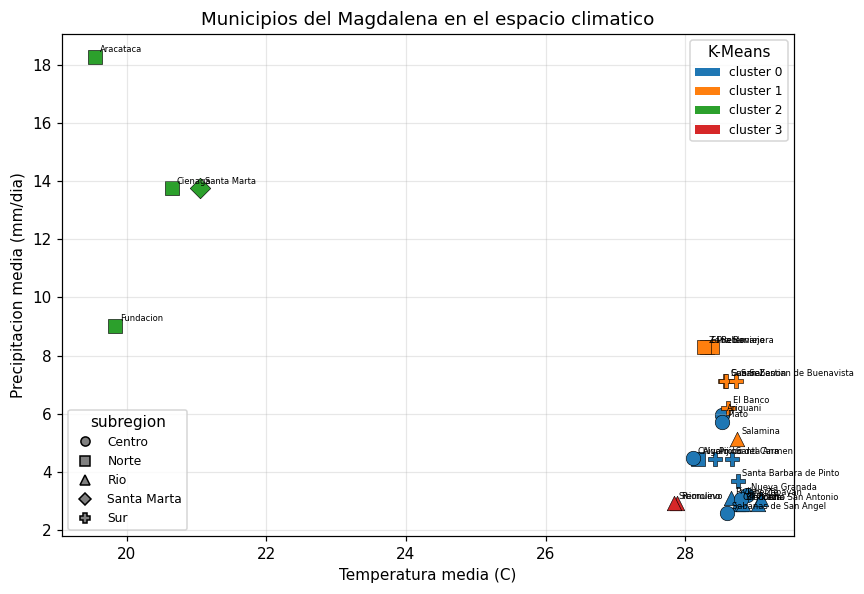

In [12]:
markers = ["o", "s", "^", "D", "P"]
sub_mk = dict(zip(subs, markers))

fig, ax = plt.subplots(figsize=(8, 5.5))
for _, r in perfil.iterrows():
    ax.scatter(r["t_media"], r["precip"], color=clu_cmap[r["cluster"]],
               marker=sub_mk[r["subregion"]], s=90, edgecolor="k", linewidth=0.4)
    ax.annotate(r["nombre_municipio"], (r["t_media"], r["precip"]), fontsize=5.5,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Temperatura media (C)"); ax.set_ylabel("Precipitacion media (mm/dia)")
ax.set_title("Municipios del Magdalena en el espacio climatico")

leg1 = ax.legend(handles=[Patch(facecolor=clu_cmap[c], label=f"cluster {c}") for c in clu],
                 loc="upper right", fontsize=8, title="K-Means")
ax.add_artist(leg1)
ax.legend(handles=[plt.Line2D([], [], marker=sub_mk[s], color="gray", linestyle="",
                              markeredgecolor="k", label=s) for s in subs],
          loc="lower left", fontsize=8, title="subregion")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 8 Hallazgos

- K-Means separa el departamento por un gradiente altitudinal (Sierra Nevada frio-humedo vs
  tierras bajas calidas), no por la logica geografica de las subregiones. El ARI bajo confirma
  que ambas particiones casi no coinciden.
- Santa Marta es su propia subregion administrativa, pero climaticamente cae junto a Aracataca,
  Cienaga y Fundacion: el cluster frio-humedo del pie de la Sierra Nevada.
- La subregion Norte es la mas heterogenea: sus municipios se reparten entre varios clusters,
  desde la Sierra Nevada hasta el llano calido.
- Remolino y Sitionuevo forman un grupo aparte por su amplitud termica muy baja: estan sobre la
  Cienaga Grande / delta del Magdalena, donde el agua amortigua la oscilacion diaria de temperatura.
- La subregion Centro es la mas coherente climaticamente: todos sus municipios caen en el mismo
  cluster calido-seco del interior.
- Implicacion para el pronostico de dengue: agrupar por subregion administrativa no equivale a
  agrupar por clima. Si el clima importa para la transmision, conviene el agrupamiento climatico.